In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.6 MB/s eta 0:00:00


In [7]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


In [39]:
DATASET = "/content/drive/MyDrive/Major_Project_AI/data/raw"

In [9]:
os.listdir(DATASET)

['rsna_dataset.zip',
 'test',
 'train',
 'valid',
 'data.yaml',
 'README.dataset.txt',
 'README.roboflow.txt']

In [10]:
train_images = os.path.join(DATASET, "train", "images")
train_labels = os.path.join(DATASET, "train", "labels")

valid_images = os.path.join(DATASET, "valid", "images")
valid_labels = os.path.join(DATASET, "valid", "labels")

test_images = os.path.join(DATASET, "test", "images")
test_labels = os.path.join(DATASET, "test", "labels")

In [40]:
print("Training Images :", len(os.listdir(train_images)))
print("Validation Images :", len(os.listdir(valid_images)))
print("Testing Images :", len(os.listdir(test_images)))

Training Images : 6999
Validation Images : 2000
Testing Images : 1000


In [37]:
print("Training Labels :", len(os.listdir(train_labels)))
print("Validation Labels :", len(os.listdir(valid_labels)))
print("Testing Labels :", len(os.listdir(test_labels)))

Training Labels : 6999
Validation Labels : 2000
Testing Labels : 1000


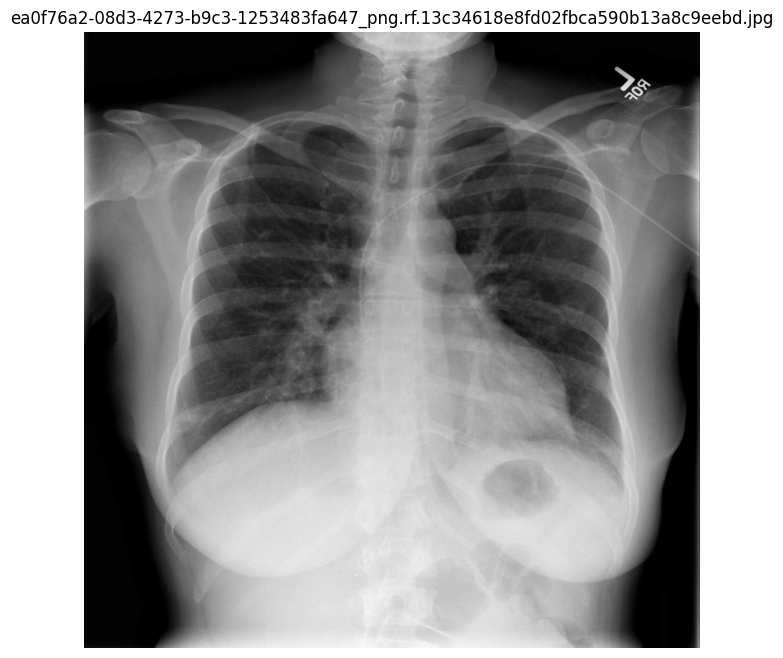

In [13]:
import random

image_name = random.choice(os.listdir(train_images))
image_path = os.path.join(train_images, image_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.title(image_name)
plt.axis("off")
plt.show()

In [15]:
height, width, channels = image.shape

print("Width :", width)
print("Height :", height)
print("Channels :", channels)

Width : 1024
Height : 1024
Channels : 3


In [16]:
widths = []
heights = []

for img_name in os.listdir(train_images):
    img_path = os.path.join(train_images, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height :", min(heights))
print("Maximum Height :", max(heights))

Minimum Width : 416
Maximum Width : 1024
Minimum Height : 416
Maximum Height : 1024


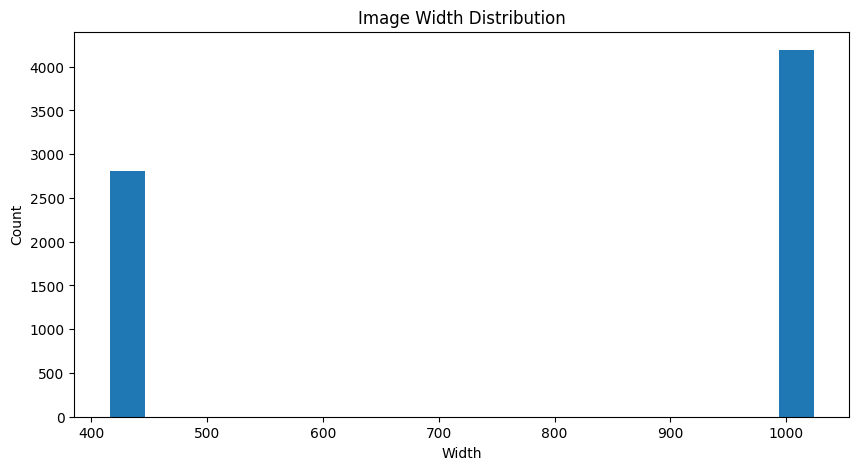

In [17]:
plt.figure(figsize=(10,5))
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Count")
plt.show()

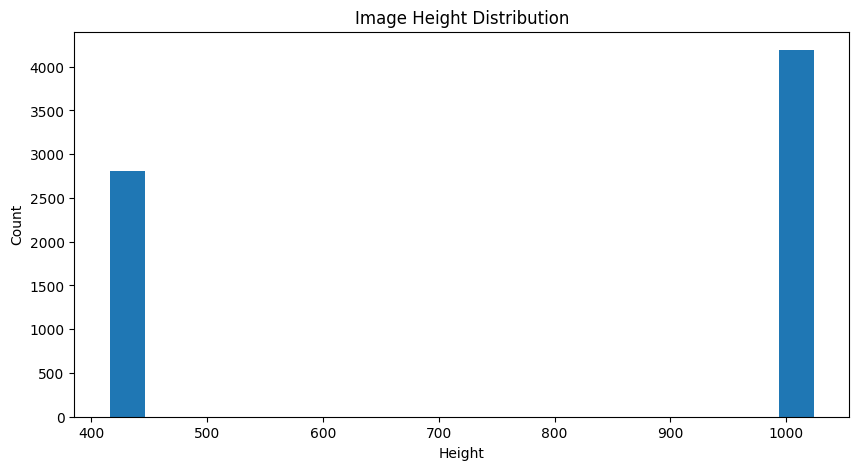

In [18]:
plt.figure(figsize=(10,5))
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

In [19]:
object_counts = []

for label_file in os.listdir(train_labels):

    path = os.path.join(train_labels, label_file)

    with open(path, "r") as f:
        lines = f.readlines()

    object_counts.append(len(lines))

print("Maximum Objects :", max(object_counts))
print("Minimum Objects :", min(object_counts))

Maximum Objects : 4
Minimum Objects : 1


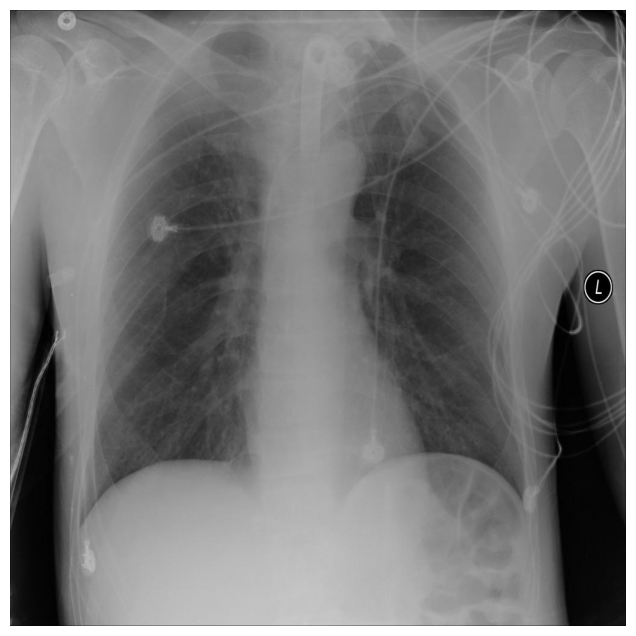

In [25]:
import random

image_name = random.choice(os.listdir(train_images))

image_path = os.path.join(train_images, image_name)

label_path = os.path.join(
    train_labels,
    image_name.replace(".jpg", ".txt").replace(".png", ".txt")
)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image.shape[:2]

if os.path.exists(label_path):

    with open(label_path, "r") as f:
        labels = f.readlines()

    for label in labels:

        cls, x, y, bw, bh = map(float, label.split())

        if bw == 0 or bh == 0:
          continue

        x *= w
        y *= h
        bw *= w
        bh *= h

        x1 = int(x - bw / 2)
        y1 = int(y - bh / 2)

        x2 = int(x + bw / 2)
        y2 = int(y + bh / 2)

        cv2.rectangle(image,
                      (x1, y1),
                      (x2, y2),
                      (255, 0, 0),
                      2)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [27]:
#This tells us how many objects belong to each class.
from collections import Counter

class_counter = Counter()

for label_file in os.listdir(train_labels):

    with open(os.path.join(train_labels, label_file), "r") as f:

        for line in f.readlines():

            values = line.strip().split()

            if len(values) != 5:
                continue

            cls, x, y, w, h = map(float, values)

            # Ignore placeholder labels
            if w == 0 or h == 0:
                continue

            class_counter[int(cls)] += 1

print("Class Distribution")
print(class_counter)

Class Distribution
Counter({1: 4442})


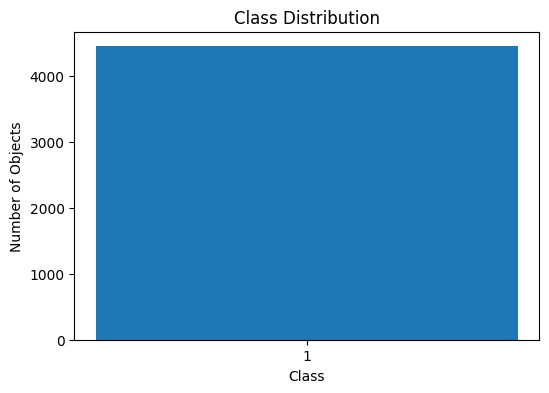

In [36]:
# Plot Class Distribution
plt.figure(figsize=(6,4))

plt.bar(
    [str(k) for k in class_counter.keys()],
    class_counter.values()
)

plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.title("Class Distribution")

plt.show()

In [29]:
missing_labels = []

for image in os.listdir(train_images):

    label = image.replace(".jpg", ".txt").replace(".png", ".txt")

    if not os.path.exists(os.path.join(train_labels, label)):
        missing_labels.append(image)

print("Missing Label Files:", len(missing_labels))

Missing Label Files: 0


In [41]:
#Corrupted images
corrupted = []

for image in os.listdir(train_images):

    path = os.path.join(train_images, image)

    img = cv2.imread(path)

    if img is None:
        corrupted.append(image)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 0


In [42]:
# Empty / Placeholder Labels
placeholder = 0
real_boxes = 0

for label_file in os.listdir(train_labels):

    with open(os.path.join(train_labels, label_file), "r") as f:

        lines = f.readlines()

    if len(lines) == 0:
        placeholder += 1
        continue

    valid = False

    for line in lines:

        values = line.strip().split()

        if len(values) != 5:
            continue

        cls, x, y, w, h = map(float, values)

        if w > 0 and h > 0:
            valid = True

    if valid:
        real_boxes += 1
    else:
        placeholder += 1

print("Images with Placeholder Labels :", placeholder)
print("Images with Real Bounding Boxes:", real_boxes)

Images with Placeholder Labels : 4194
Images with Real Bounding Boxes: 2805


In [43]:
# Final DataSet Summary
print("=" * 50)

print("RSNA Pneumonia Dataset Summary")

print("=" * 50)

print(f"Training Images      : {len(os.listdir(train_images))}")
print(f"Validation Images    : {len(os.listdir(valid_images))}")
print(f"Testing Images       : {len(os.listdir(test_images))}")

print()

print(f"Missing Labels       : {len(missing_labels)}")
print(f"Corrupted Images     : {len(corrupted)}")

print()

print(f"Placeholder Labels   : {placeholder}")
print(f"Real Bounding Boxes  : {real_boxes}")

print()

print("EDA Completed Successfully")

RSNA Pneumonia Dataset Summary
Training Images      : 6999
Validation Images    : 2000
Testing Images       : 1000

Missing Labels       : 0
Corrupted Images     : 0

Placeholder Labels   : 4194
Real Bounding Boxes  : 2805

EDA Completed Successfully
